# The Ising Model — an interactive tutorial

A visual walk-through of [Karpathy's Ising example](https://cs.stanford.edu/people/karpathy/visml/ising_example.html). The Ising model is the *hello world* of statistical physics and graphical models: a grid of binary spins that prefer to agree (or disagree) with their neighbours. From this single rule we get magnets, phase transitions, and an image-denoising algorithm — all sampled with a few lines of Metropolis.

By the end you should have intuition for:

- what the **energy** $E(x)$ measures, and how the coupling $J$ controls *smoothness*
- how the **Boltzmann distribution** $p(x) \propto e^{-E(x)/T}$ and **temperature** $T$ trade off energy vs. entropy
- how **Metropolis** turns that distribution into samples by accepting or rejecting single-spin flips
- the **phase transition** between ordered and disordered regimes
- how an external field $b$ lets us **denoise images** with the Ising prior

Every section has a small live experiment — run the cells in order, then play with the parameters.

## 1. The lattice

We have an $N \times N$ grid of binary spins $x_i \in \{-1, +1\}$. Each interior spin has 4 neighbours (up / down / left / right). That's the entire state space.

Visually, $-1$ and $+1$ are two colours, so any configuration is just a black-and-white image. Below is a random one — every pixel is an independent fair coin flip.

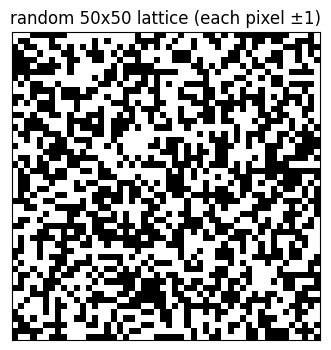

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
N = 50
x_random = rng.choice([-1, 1], size=(N, N))

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(x_random, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
ax.set_title(f"random {N}x{N} lattice (each pixel ±1)")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 2. The energy

Karpathy's energy:

$$E(x) \;=\; -\,J \!\!\sum_{(i,j)\in E}\! x_i x_j \;-\; J_b \sum_{i\in V} b_i\, x_i$$

Two terms, each a *preference*:

| term | meaning | favours |
|---|---|---|
| $-J \sum_{(i,j)} x_i x_j$ | every neighbour pair contributes $-J\,x_i x_j$ | $J>0$: agreeing neighbours $\Rightarrow$ **smooth blobs**. $J<0$: disagreeing neighbours $\Rightarrow$ **checkerboard**. |
| $-J_b \sum_i b_i x_i$ | per-pixel external field $b_i \in \{-1,+1\}$ | each spin to match its bias $b_i$, with strength $J_b$ |

Lower energy = more probable. The energy is just a scoreboard: *how unhappy is this configuration?*

Let's check the numbers on three hand-picked configurations. With $J=+1$, the all-aligned image should win; with $J=-1$, the checkerboard should win.

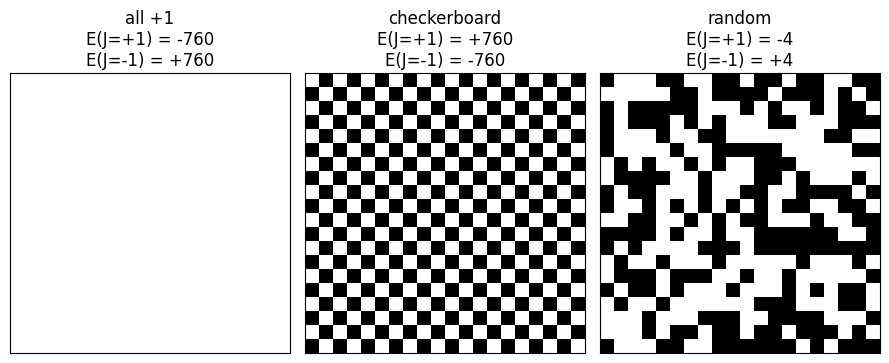

In [5]:
def energy(x, J=1.0, Jb=0.0, b=None):
    """Total Ising energy. No periodic boundary."""
    pairs = (x[1:, :] * x[:-1, :]).sum() + (x[:, 1:] * x[:, :-1]).sum()
    field = (b * x).sum() if b is not None else 0.0
    return -J * pairs - Jb * field

N = 20
all_up = np.ones((N, N), dtype=np.int8)
checker = np.indices((N, N)).sum(axis=0) % 2
checker = np.where(checker == 0, 1, -1).astype(np.int8)
random_cfg = np.random.default_rng(1).choice([-1, 1], size=(N, N)).astype(np.int8)

configs = [("all +1", all_up), ("checkerboard", checker), ("random", random_cfg)]
fig, axes = plt.subplots(1, 3, figsize=(9, 3.6))
for ax, (name, cfg) in zip(axes, configs):
    ax.imshow(cfg, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"{name}\nE(J=+1) = {energy(cfg, J=+1):+.0f}\nE(J=-1) = {energy(cfg, J=-1):+.0f}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. From energy to probability — the Boltzmann distribution

We want a probability distribution over configurations. The standard recipe:

$$p(x) \;\propto\; \pi(x) \;=\; e^{-E(x)/T}$$

where $T>0$ is the **temperature**.

- $T \to 0$: only the lowest-energy state(s) survive — frozen, deterministic.
- $T \to \infty$: $e^{-E/T} \to 1$ for every state — uniform — pure noise.
- in between: a tradeoff between *low energy* and *many configurations like this exist* (entropy).

The normalising constant $Z = \sum_x \pi(x)$ sums over $2^{N^2}$ configurations — for $N=50$ that's $2^{2500}$ terms. We never compute it. Metropolis only needs *ratios* $\pi(x')/\pi(x)$, and those depend on a **local** energy difference.

## 4. Metropolis single-spin-flip sampler

Karpathy's pseudocode:

```
x = randomState()
while true:
    px   = pi(x)
    xnew = flipOneBit(x)
    pnew = pi(xnew)
    alpha = min(1, pnew / px)
    if uniform(0,1) < alpha:
        x = xnew
```

The clever bit: flipping spin $x_i$ only changes the energies of the bonds touching $i$. If $S_i$ is the sum of its 4 neighbours,

$$\Delta E \;=\; E(x') - E(x) \;=\; 2\,J\,x_i\,S_i \;+\; 2\,J_b\,b_i\,x_i$$

so the acceptance probability is just $\min\!\big(1,\; e^{-\Delta E/T}\big)$ — a few multiplications per site. We never touch $Z$.

> **Why this works.** This rule satisfies *detailed balance* with respect to $p(x) \propto e^{-E/T}$, so the chain's stationary distribution is exactly the Boltzmann distribution we want.

Below is a vectorised implementation. Standard Metropolis updates one site at a time, but on a 4-neighbour grid the spins split into two independent *colours* (like a checkerboard); we can update an entire colour in parallel and the chain is still correct.

In [7]:
def metropolis_sweep(x, J=1.0, T=1.0, Jb=0.0, b=None, rng=None):
    """One sweep ~ N*N attempted flips, via two parallel half-updates."""
    rng = rng or np.random.default_rng()
    ii, jj = np.indices(x.shape)
    parity = (ii + jj) % 2  # 0 = red, 1 = black

    for color in (0, 1):
        nb = np.zeros_like(x, dtype=np.int32)
        nb[1:, :]  += x[:-1, :]
        nb[:-1, :] += x[1:, :]
        nb[:, 1:]  += x[:, :-1]
        nb[:, :-1] += x[:, 1:]

        dE = 2.0 * J * x * nb
        if b is not None:
            dE = dE + 2.0 * Jb * b * x

        # accept with prob min(1, exp(-dE/T))
        accept = rng.random(x.shape) < np.exp(-np.maximum(dE, 0.0) / T)
        flip = accept & (parity == color)
        x = np.where(flip, -x, x).astype(np.int8)
    return x


def sample(N=80, J=1.0, T=1.0, Jb=0.0, b=None, n_sweeps=80, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.choice([-1, 1], size=(N, N)).astype(np.int8)
    for _ in range(n_sweeps):
        x = metropolis_sweep(x, J=J, T=T, Jb=Jb, b=b, rng=rng)
    return x

### Watch order emerge from noise

Start from random spins and run the sampler at $J=+1, T=1$ (well below the critical temperature). Tiny same-coloured patches grow, merge, and eventually one colour dominates — *coarsening*. The lattice is finding low-energy configurations on its own.

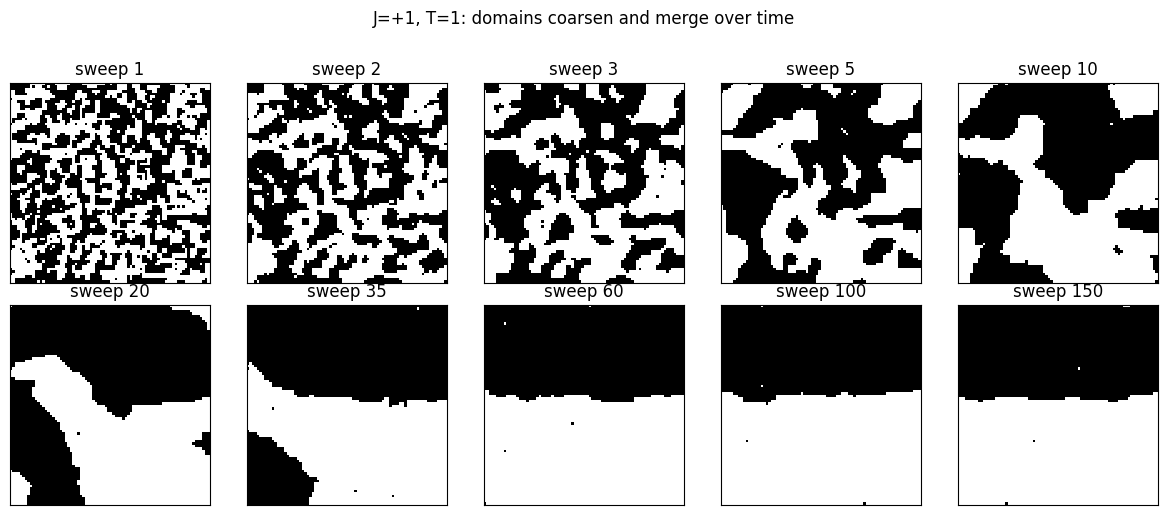

In [9]:
snap_at = [1, 2, 3, 5, 10, 20, 35, 60, 100, 150]
rng = np.random.default_rng(2)
x = rng.choice([-1, 1], size=(80, 80)).astype(np.int8)
snaps = []
for s in range(1, max(snap_at) + 1):
    x = metropolis_sweep(x, J=1.0, T=1.0, rng=rng)
    if s in snap_at:
        snaps.append((s, x.copy()))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, (s, snap) in zip(axes.flat, snaps):
    ax.imshow(snap, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"sweep {s}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("J=+1, T=1: domains coarsen and merge over time", y=1.02)
plt.tight_layout(); plt.show()

### Sign of $J$ flips the geometry

Same code, two values of $J$. The *only* difference is whether neighbours want to agree or disagree.

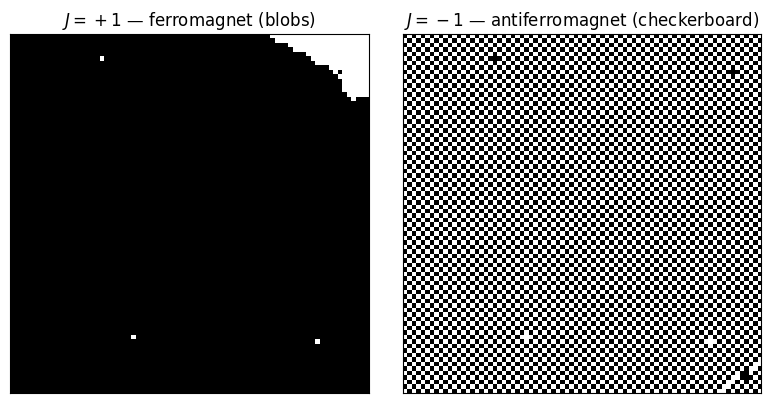

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, J, title in [(axes[0], +1.0, r"$J=+1$ — ferromagnet (blobs)"),
                     (axes[1], -1.0, r"$J=-1$ — antiferromagnet (checkerboard)")]:
    x = sample(N=80, J=J, T=1.0, n_sweeps=80, seed=0)
    ax.imshow(x, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 5. Temperature: order, criticality, chaos

For the 2D Ising model on a square lattice with $J=1$ there's a famous **critical temperature**

$$T_c \;=\; \frac{2}{\ln(1+\sqrt{2})} \;\approx\; 2.269$$

(Onsager, 1944). Below $T_c$ the system is *ordered* — one colour wins, with a few thermal fluctuations. Above $T_c$ it's *disordered* — high-entropy noise. Right at $T_c$ you see scale-invariant critical fluctuations: patches of every size at once. Three snapshots:

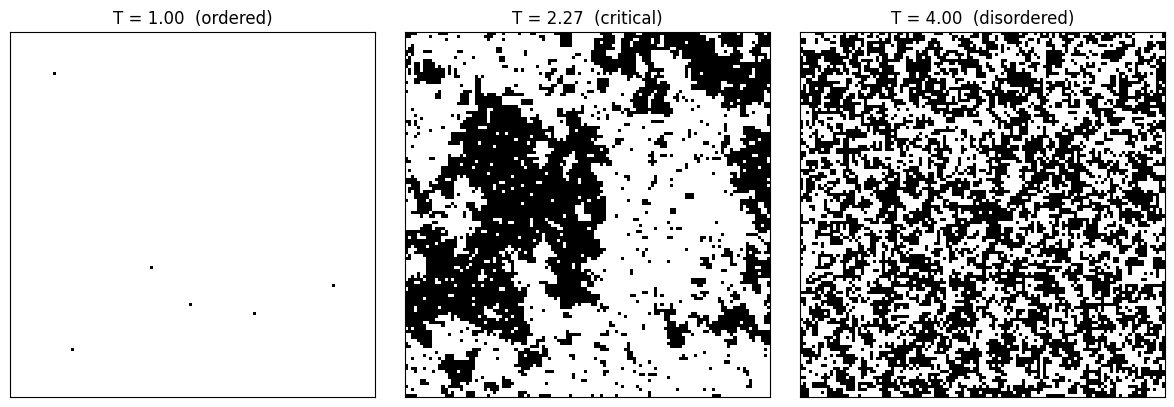

In [13]:
Ts = [1.0, 2.27, 4.0]
labels = ["ordered", "critical", "disordered"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, T, lab in zip(axes, Ts, labels):
    x = sample(N=120, J=1.0, T=T, n_sweeps=200, seed=3)
    ax.imshow(x, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"T = {T:.2f}  ({lab})")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### Tracking observables

Two scalars summarise the lattice: **magnetisation** $m = \frac{1}{N^2}\sum_i x_i$ (between $-1$ and $+1$) and **energy per spin** $E/N^2$. Plotting them through time shows the phase transition quantitatively: at $T<T_c$, $|m|$ saturates near 1; at $T>T_c$, it stays near 0; near $T_c$, it fluctuates wildly.

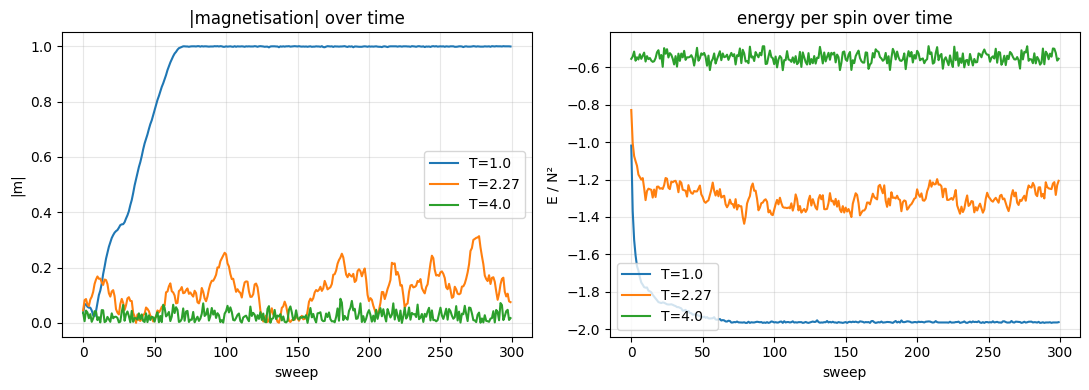

In [15]:
def trace(N=60, J=1.0, T=1.0, n_sweeps=300, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.choice([-1, 1], size=(N, N)).astype(np.int8)
    mag, en = [], []
    for _ in range(n_sweeps):
        x = metropolis_sweep(x, J=J, T=T, rng=rng)
        mag.append(x.mean())
        en.append(energy(x, J=J) / x.size)
    return np.array(mag), np.array(en)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for T, color in [(1.0, "C0"), (2.27, "C1"), (4.0, "C2")]:
    m, e = trace(T=T, seed=1)
    axes[0].plot(np.abs(m), color=color, label=f"T={T}")
    axes[1].plot(e, color=color, label=f"T={T}")
axes[0].set_xlabel("sweep"); axes[0].set_ylabel("|m|"); axes[0].set_title("|magnetisation| over time")
axes[1].set_xlabel("sweep"); axes[1].set_ylabel("E / N²"); axes[1].set_title("energy per spin over time")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. External field — denoising as inference

Now turn on $J_b > 0$ with $b_i$ = the **observed** noisy pixels. The model now says:

> *I want my spins to (a) match the observation $b$ (strength $J_b$) AND (b) be smooth like a real image (strength $J$).*

That's literally a smoothness *prior* + observation *likelihood*. Running Metropolis is now image denoising. Same model, same code — only the inputs change.

We corrupt a clean disk with random pixel flips, hand the noisy image to the sampler as the field $b$, and run a few sweeps.

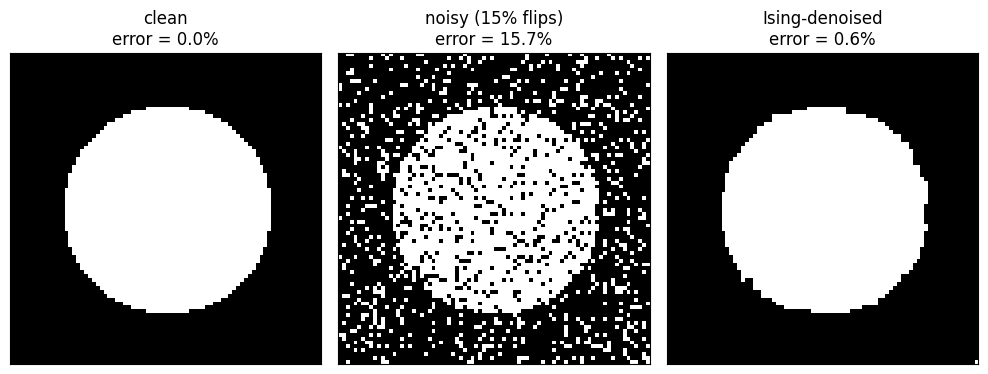

In [17]:
N = 80
yy, xx = np.indices((N, N))
clean = np.where((xx - N/2)**2 + (yy - N/2)**2 < (N/3)**2, 1, -1).astype(np.int8)

flip_p = 0.15
flips = np.random.default_rng(0).random((N, N)) < flip_p
noisy = np.where(flips, -clean, clean).astype(np.int8)

def denoise(noisy, J=1.0, T=0.5, Jb=1.0, n_sweeps=80, seed=0):
    """Initialise from the noisy image (faster than from random) and sample."""
    rng = np.random.default_rng(seed)
    x = noisy.copy().astype(np.int8)
    b = noisy.astype(np.float32)
    for _ in range(n_sweeps):
        x = metropolis_sweep(x, J=J, T=T, Jb=Jb, b=b, rng=rng)
    return x

denoised = denoise(noisy, J=1.0, T=0.5, Jb=1.0, n_sweeps=80)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, img, title in zip(axes,
                          [clean, noisy, denoised],
                          ["clean", f"noisy ({int(flip_p*100)}% flips)", "Ising-denoised"]):
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    err = (img != clean).mean()
    ax.set_title(f"{title}\nerror = {err:.1%}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 7. Play with it

Drag the sliders. Things to try:

1. **Sweep $T$** with $J=+1$ — order disappears around $T \approx 2.3$.
2. **Flip $J$ negative** — checkerboard (and notice the critical temperature changes too).
3. **Set $J\approx 0$** — pure noise; the prior has no opinion.
4. **Crank `sweeps`** — large blobs only emerge with enough mixing time.

> Requires `ipywidgets`. If sliders don't render, install with `pip install ipywidgets` and restart the kernel — the static cells above already cover the same ground.

In [19]:
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    have_widgets = True
except ImportError:
    have_widgets = False
    print("ipywidgets not installed — run `pip install ipywidgets` to enable interactivity.")

if have_widgets:
    @interact(
        J=FloatSlider(value=1.0, min=-2.0, max=2.0, step=0.1, description="J"),
        T=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description="T"),
        sweeps=IntSlider(value=60, min=1, max=300, step=1, description="sweeps"),
        N=IntSlider(value=80, min=20, max=160, step=20, description="N"),
        seed=IntSlider(value=0, min=0, max=20, step=1, description="seed"),
    )
    def _interactive(J, T, sweeps, N, seed):
        x = sample(N=N, J=J, T=T, n_sweeps=sweeps, seed=seed)
        m = x.mean()
        e = energy(x, J=J) / x.size
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(x, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
        ax.set_title(f"J={J:+.1f}, T={T:.2f}, sweeps={sweeps}\n"
                     f"<m> = {m:+.3f},  E/N² = {e:+.3f}")
        ax.set_xticks([]); ax.set_yticks([])
        plt.show()

ipywidgets not installed — run `pip install ipywidgets` to enable interactivity.


## Takeaways

- The Ising model is a **probability distribution over images** with a one-line energy.
- $J$ controls the **smoothness prior** (sign matters: $+$ → blobs, $-$ → checkerboard).
- $T$ controls **how peaked** the distribution is around low-energy states; there's a sharp phase transition at $T_c \approx 2.27$.
- Metropolis only ever needs **local energy differences** — we never compute the partition function $Z$.
- Same model, different inputs → physics simulation, denoiser, segmentation prior, … the Ising model is the world's smallest Markov random field.

### Where to go next

- Mean-field / belief propagation as deterministic alternatives to MCMC.
- Replace ±1 spins with $K$-state **Potts** spins → multi-class image segmentation.
- Replace pairwise potentials with learned ones → conditional random fields, modern energy-based models.